# SAC Training Session

In [1]:
from RL.trainer import SACTrajectoryTrainer

In [ ]:
trainer = SACTrajectoryTrainer(
    "Settings/SAC_parameters.yaml",
    verbose=True,
    run_zero_waypoint_episode=True
    )

[ SAC ]> Loading configuration from Settings/SAC_parameters.yaml
[ SAC_COST ]> No configuration file provided, using default settings.


### Plotting simulation world from top

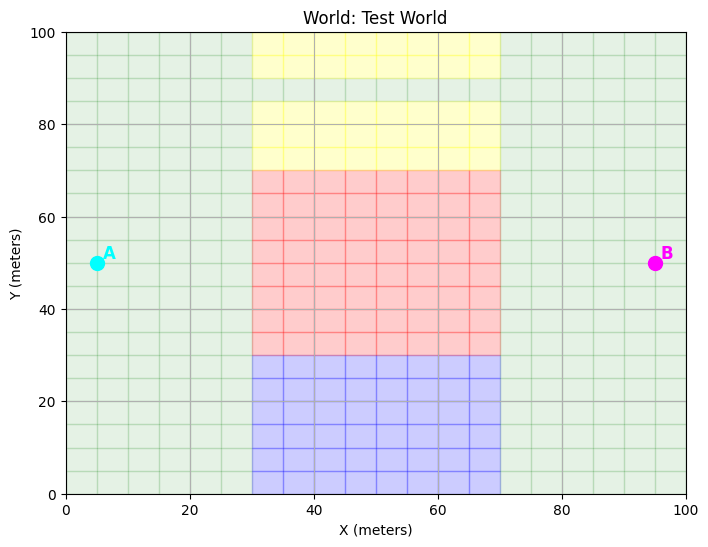

In [3]:
trainer.simulation_object.world.plot_world_from_top(A=trainer.start_point,
                                                    B=trainer.end_point)

### Plot a map of search regions
Here, boundary search for each reference point are plotted in a 2D map

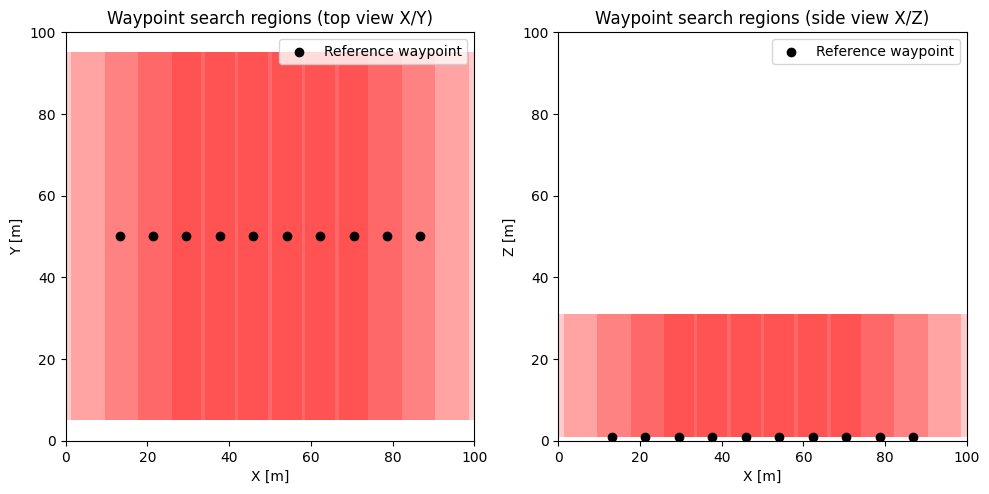

(<Figure size 1000x600 with 2 Axes>,
 array([<Axes: title={'center': 'Waypoint search regions (top view X/Y)'}, xlabel='X [m]', ylabel='Y [m]'>,
        <Axes: title={'center': 'Waypoint search regions (side view X/Z)'}, xlabel='X [m]', ylabel='Z [m]'>],
       dtype=object))

In [4]:
trainer.environment.plot_waypoint_search_regions(alpha=0.20, figsize=(10, 6))

## Starting training

In [5]:
trainer.start_optimization()

[ SAC_COST ]> No configuration file provided, using default settings.
[ SAC_COST ]> No configuration file provided, using default settings.


ValueError: Expected parameter loc (Tensor of shape (1, 5)) of distribution Normal(loc: torch.Size([1, 5]), scale: torch.Size([1, 5])) to satisfy the constraint Real(), but found invalid values:
tensor([[nan, nan, nan, nan, nan]], device='cuda:0')

In [ ]:
print(f"Best cost: {trainer.best_cost}")
print(f"Episodes: {len(trainer.costs_history)}")
best_params = trainer.best_params
print("Best parameters found by RL agent:", best_params)

In [ ]:
# Import best trajectory found by RL agent into main simulation for visualization and analysis
from main import *
from Optimizations.optimizer import Optimizer as CostWrapper
from Utils.plotting_functions import show2DWorld, show3DWorld


parameters = trainer.simulation_parameters
init_state = create_initial_state(*trainer.start_point)
waypoints_selected = best_params

thrust_max = get_max_thrust_from_rotor_model(parameters)
pid_gains = load_pid_gains(parameters)
quad_controller = create_quadcopter_controller(init_state, pid_gains, thrust_max, parameters)
drone = create_quadcopter_model(init_state, quad_controller, parameters)
world = World.load_world(parameters['world_data_path'])
noise_model = load_dnn_noise_model(parameters)

A = parameters['start_point']
B = parameters['end_point']

sim = Simulation(
    drone,
    world,
    waypoints_selected,
    dt=float(parameters['dt']),
    max_simulation_time=float(parameters['simulation_time']),
    frame_skip=int(parameters['frame_skip']),
    target_reached_threshold=float(parameters['threshold']),
    target_shift_threshold_distance=float(parameters['target_shift_threshold_distance']),
    noise_model=noise_model,
    generate_sound_emission_map=True,
    compute_psychoacoustics=False,
    noise_annoyance_radius=9,
)

cw = CostWrapper(sim, "")

cw.simulation_object.startSimulation(stop_at_target=True, use_static_target=False, verbose=True)
print(f"Costs: {cw.calculate_costs()}")
max_world_size = cw.simulation_object.world.max_world_size
show2DWorld(
    world, cw.simulation_object.positions, A, B, waypoints_selected, horiz_speed_history=cw.simulation_object.horiz_speed_history, vertical_speed_history=cw.simulation_object.vertical_speed_history)

In [ ]:
show3DWorld(
    world, cw.simulation_object.positions, A, B, waypoints_selected, 
    horiz_speed_history=cw.simulation_object.horiz_speed_history, 
    vertical_speed_history=cw.simulation_object.vertical_speed_history,
    view_pov=(30, 45))

In [ ]:
# # Plot SPL history and SWL history in subplots
# import matplotlib.pyplot as plt
# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
# ax1.plot(cw.simulation_object.time_history, cw.simulation_object.spl_history, label='SPL (dB)')
# ax1.set_xlabel('Time (s)')
# ax1.set_ylabel('SPL (dB)')
# ax1.set_title(f'Sound Pressure Level (SPL) over Time [Averaged: {np.mean(cw.simulation_object.spl_history):.2f} dB]')
# ax1.grid()
# ax1.legend()
# ax2.plot(cw.simulation_object.time_history, cw.simulation_object.swl_history, label='SWL (dB)', color='orange')
# ax2.set_xlabel('Time (s)')
# ax2.set_ylabel('SWL (dB)')
# ax2.set_title(f'Sound Power Level (SWL) over Time [Averaged: {np.mean(cw.simulation_object.swl_history):.2f} dB]')
# ax2.grid()
# ax2.legend()
# plt.tight_layout()
# plt.show()